# LoRA/QLoRA Fine-tuning — End-to-End Walkthrough

This notebook walks through the complete pipeline:
1. Environment setup & dependencies
2. Load & inspect a domain dataset
3. Load base model with 4-bit QLoRA quantization
4. Attach LoRA adapters & inspect trainable parameters
5. Train with SFTTrainer
6. Evaluate: perplexity, ROUGE, BERTScore
7. Merge adapter to standalone model
8. Interactive inference demo

## 1. Install Dependencies

In [1]:
import os
os.chdir('..')
os.getcwd()

'/teamspace/studios/this_studio'

In [2]:
# Run once
# !pip install -q transformers datasets peft trl bitsandbytes accelerate
# !pip install -q rouge-score bert-score wandb rich
import sys
print(f'Python {sys.version}')

import torch
print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Python 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:09:17) [GCC 11.2.0]


PyTorch 2.8.0+cu128 | CUDA available: True
GPU: NVIDIA L40S | VRAM: 47.7 GB


## 2. Dataset Exploration

In [3]:
from datasets import load_dataset
import pandas as pd

# Using the Alpaca dataset as a universal demo
dataset = load_dataset('tatsu-lab/alpaca', split='train')
print(f'Dataset size: {len(dataset):,} samples')
print(f'Columns: {dataset.column_names}')
dataset.to_pandas().head(3)

Dataset size: 52,002 samples
Columns: ['instruction', 'input', 'output', 'text']


,instruction,input,output,text
0,Give three tips for staying healthy.,,1.Eat a balanced diet and make sure to include...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,"An atom is made up of a nucleus, which contain...",Below is an instruction that describes a task....


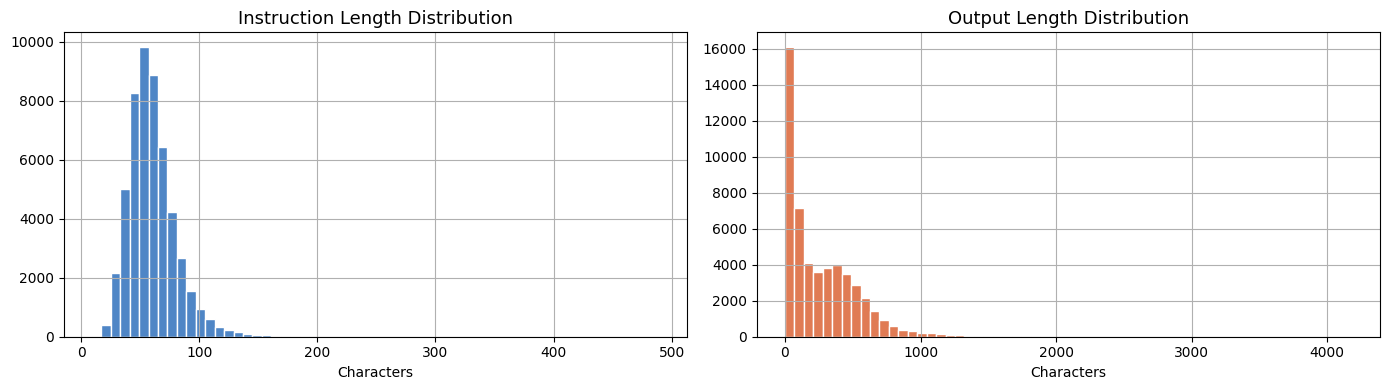

Instruction — mean: 60 | min: 9 | max: 489
Output      — mean: 270 | min:0 | max: 4181


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Analyse instruction/output length distributions
df = dataset.to_pandas()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['instruction'].str.len().hist(bins=60, ax=axes[0], color='#4f86c6', edgecolor='white')
axes[0].set_title('Instruction Length Distribution', fontsize=13)
axes[0].set_xlabel('Characters')

df['output'].str.len().hist(bins=60, ax=axes[1], color='#e07b54', edgecolor='white')
axes[1].set_title('Output Length Distribution', fontsize=13)
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()
print(f"Instruction — mean: {df['instruction'].str.len().mean():.0f} | min: {df['instruction'].str.len().min()} | max: {df['instruction'].str.len().max()}")
print(f"Output      — mean: {df['output'].str.len().mean():.0f} | min:{df['output'].str.len().min()} | max: {df['output'].str.len().max()}")

## 3. Prepare Data — Alpaca Instruction Format

In [5]:
import sys; sys.path.append('../src')
from src.data_utils import text_to_alpaca, train_val_test_split, mask_prompt_tokens
from datasets import Dataset

INSTRUCTION_TEMPLATE = '### Instruction:\n'
RESPONSE_TEMPLATE = '### Response:\n'

def format_sample(row):
    return {'text': text_to_alpaca(row)}

formatted = dataset.map(format_sample, num_proc=4)
splits = train_val_test_split(formatted, val_ratio=0.05, test_ratio=0.05)
print(splits)
print('\n--- Example formatted sample ---')
print(splits['train'][0]['text'][:500])

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 46802
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 2600
    })
    test: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 2600
    })
})

--- Example formatted sample ---
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Devise a scenario where two machines can cooperate autonomously with each other.

### Response:
A scenario where two machines can cooperate autonomously is a robotic assistant system. The two machines can be programmed to take on tasks and interact with each other in order to complete those tasks. For example, one machine can be programmed to perform tasks such as finding i


## 4. Load Model with QLoRA (4-bit)

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

MODEL_NAME = 'mistralai/Mistral-7B-v0.1'  # swap for any CausalLM

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side='right')
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.bfloat16,
)
base_model = prepare_model_for_kbit_training(base_model)
print('>>>>Base model loaded with 4-bit quantization')

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

>>>>Base model loaded with 4-bit quantization


## 5. Attach LoRA Adapters

In [7]:
lora_config = LoraConfig(
    r=64,                  # rank — higher = more capacity, more params
    lora_alpha=16,         # scaling factor
    target_modules=[       # which weight matrices to adapt
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# Visualise adapter parameter distribution
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params:     {total/1e9:.2f}B')
print(f'Trainable params: {trainable/1e6:.2f}M  ({100*trainable/total:.3f}%)')

trainable params: 167,772,160 || all params: 7,409,504,256 || trainable%: 2.2643

Total params:     3.92B
Trainable params: 167.77M  (4.280%)


## 6. Train with SFTTrainer

In [8]:
from transformers import TrainingArguments, EarlyStoppingCallback
from trl.trainer.sft_trainer import SFTTrainer
from src.data_utils import mask_prompt_tokens
import torch
#from trl.trainer import DataCollatorForCompletionOnlyLM

OUTPUT_DIR = './outputs/alpaca-lora-demo'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,               # increase for production
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,    # effective batch = 16
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_steps=3,
    bf16=True,
    logging_steps=25,
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    optim='paged_adamw_32bit',
    max_grad_norm=0.3,
  #  group_by_length=True,
    report_to='wandb',  # set to 'wandb' for experiment tracking
)

collator = mask_prompt_tokens(tokenizer=tokenizer,
    prompt_template=INSTRUCTION_TEMPLATE,
    response_template=RESPONSE_TEMPLATE,
)

trainer = SFTTrainer(
    model=model,
  #  tokenizer=tokenizer,
    train_dataset=splits['train'],
    eval_dataset=splits['validation'],
  #  dataset_text_field='text',
    data_collator=collator,
 #   max_seq_length=2048,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

/home/zeus/miniconda3/envs/cloudspace/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/zeus/miniconda3/envs/cloudspace/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.882866,0.869384,0.847692,191836.000000,0.768395
200,0.875634,0.862820,0.875075,382845.000000,0.769206
300,0.881758,0.859175,0.880593,576093.000000,0.770294
400,0.902197,0.858506,0.897649,767010.000000,0.769909
500,0.866563,0.858424,0.878536,957029.000000,0.770125
600,0.878751,0.856618,0.868920,1147655.000000,0.770478
700,0.878228,0.855172,0.862398,1341740.000000,0.770365
800,0.867349,0.856529,0.884537,1533541.000000,0.770181
900,0.871447,0.854770,0.877313,1726227.000000,0.770946
1000,0.866215,0.852946,0.850770,1915934.000000,0.771281


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=2926, training_loss=0.864433898941263, metrics={'train_runtime': 9101.0125, 'train_samples_per_second': 5.143, 'train_steps_per_second': 0.322, 'total_flos': 3.80816047729066e+17, 'train_loss': 0.864433898941263, 'epoch': 1.0})

## 7. Evaluate: Loss Curve + Perplexity

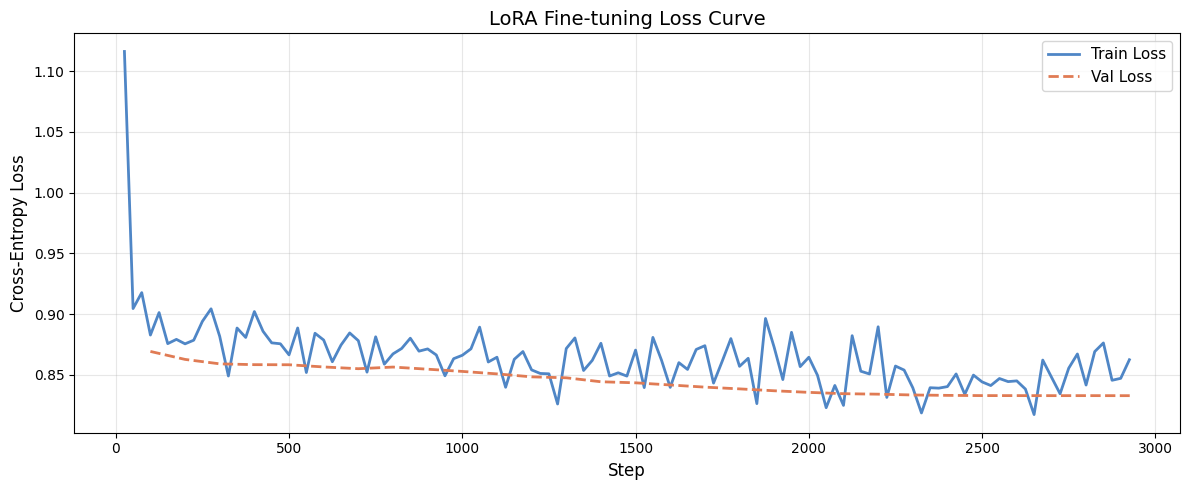

In [13]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_steps = [l['step'] for l in logs if 'loss' in l and 'eval_loss' not in l]
train_loss  = [l['loss'] for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_steps  = [l['step'] for l in logs if 'eval_loss' in l]
eval_loss   = [l['eval_loss'] for l in logs if 'eval_loss' in l]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_steps, train_loss, label='Train Loss', color='#4f86c6', linewidth=2)
ax.plot(eval_steps, eval_loss, label='Val Loss', color='#e07b54', linewidth=2, linestyle='--')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('LoRA Fine-tuning Loss Curve', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("docs/", exist_ok=True)
plt.savefig('./docs/loss_curve.png', dpi=150)
plt.show()

In [16]:
import sys; sys.path.append('../src')
from src.evaluate import compute_perplexity, compute_rouge

test_texts = [splits['test'][i]['text'] for i in range(min(50, len(splits['test'])))]
ppl_results = compute_perplexity(model, tokenizer, test_texts[:20])
print('Perplexity on test set:')
for k, v in ppl_results.items():
    print(f'  {k}: {v}')

Computing perplexity: 100%|██████████| 20/20 [00:02<00:00,  8.90it/s]

Perplexity on test set:
  perplexity_mean: 2.1615
  perplexity_std: 0.5813
  perplexity_median: 1.9341


## 8. Save & Merge Adapter

In [17]:
# Save adapter only (small — ~100MB for r=64)
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Adapter saved to {OUTPUT_DIR}')

# Optional: merge into full model (for deployment)
# from inference import merge_and_save
# merge_and_save(MODEL_NAME, OUTPUT_DIR, '../outputs/alpaca-merged')

Adapter saved to ./outputs/alpaca-lora-demo


## 9. Inference Demo

In [18]:
from peft import PeftModel
import torch

model.eval()

def generate(prompt, max_new_tokens=256, temperature=0.7):
    full_prompt = f'### Instruction:\n{prompt}\n\n### Response:\n'
    inputs = tokenizer(full_prompt, return_tensors='pt').to(model.device)
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    return decoded[len(full_prompt):].strip()

# --- Try it out ---
test_prompts = [
    'Explain the difference between supervised and unsupervised learning.',
    'Write a Python function that checks if a string is a palindrome.',
    'What are the key principles of SOLID software design?',
]

for prompt in test_prompts:
    print(f'\n>>> Prompt: {prompt}')
    print(f'>>> Response: {generate(prompt)}')
    print('-' * 70)


>>> Prompt: Explain the difference between supervised and unsupervised learning.
>>> Response: Supervised learning is a type of machine learning algorithm in which labeled data is used to train the model. The model learns from labeled examples and is then able to make predictions on new, unseen data. Unsupervised learning is a type of machine learning algorithm in which unlabeled data is used to train the model. The model learns from patterns in the data and is then able to cluster or group similar items together. Supervised learning is better suited for tasks that require precise results while unsupervised learning is better suited for tasks that require finding patterns or relationships in data.
----------------------------------------------------------------------

>>> Prompt: Write a Python function that checks if a string is a palindrome.
>>> Response: def is_palindrome(s): 
    # Convert the given string to all lower case
    s = s.lower() 
  
    # Check if the length of the st